# 53 Boost 2 — XGBoost, GradientBoosting y AdaBoost

Tres algoritmos de boosting sobre `sale` y `rent` prediciendo `log_precio`.

- Features fijas definidas manualmente (ya numéricas/binarias)
- Municipios con < 10 observaciones se unifican en `municipio_otro`
- Split 80/20 train-test, CV de 5 folds
- Primero modelo base (hiperparámetros por defecto) y luego GridSearchCV

## Configuracion y rutas
Parametros globales y rutas de datasets.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
)
from sklearn.model_selection import train_test_split, GridSearchCV

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)

# ── Configuración ─────────────────────────────────────────────────────────────
RANDOM_STATE      = 42
TEST_SIZE         = 0.20
TARGET_COL        = "log_precio"
CV_FOLDS          = 5

# ── Rutas ─────────────────────────────────────────────────────────────────────
def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "gold").exists():
            return p
    raise FileNotFoundError("No se encontró la raíz del proyecto (data/gold)")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATASETS = {
    "sale": PROJECT_ROOT / "data" / "gold" / "final_sale_idealistaAPI.csv",
    "rent": PROJECT_ROOT / "data" / "gold" / "final_rent_idealistaAPI.csv",
}

print("Datasets:")
for name, path in DATASETS.items():
    print(f"  {name}: {path}")

Datasets:
  sale: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_sale_idealistaAPI.csv
  rent: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_rent_idealistaAPI.csv


## Features y grids
Definicion de variables y espacios de busqueda.

In [2]:
# ── Features ──────────────────────────────────────────────────────────────────
BASE_FEATURES = [
    "superficie_construida_m2",
    "numero_dormitorios",
    "numero_banos",
    # "latitud",
    # "longitud",
    "tiene_garaje",
    "obra_nueva",
    "distancia_min_playa_km",
    "distancia_min_supermercado_km",
    "distancia_min_colegio_km",
    "distancia_centro_municipio_km",
    # "score_cercania_servicios",
    "tipologia_unificada_piso",
    "tipologia_unificada_unifamiliar",
]


# ── Hiperparámetros: grids de búsqueda ────────────────────────────────────────
PARAM_GRID_XGB = {
    "n_estimators":     [200, 400],
    "max_depth":        [3, 4, 5],
    "learning_rate":    [0.05, 0.1],
    "subsample":        [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9],
    "min_child_weight": [3, 5],
    "reg_lambda":       [1, 5],
}

PARAM_GRID_GBR = {
    "n_estimators":    [200, 400],
    "max_depth":       [3, 4, 5],
    "learning_rate":   [0.05, 0.1],
    "subsample":       [0.7, 0.9],
    "min_samples_leaf": [5, 10],
}

PARAM_GRID_ADA = {
    "n_estimators":         [100, 200, 400],
    "learning_rate":        [0.5, 1.0, 1.5],
    "estimator__max_depth": [3, 5, 7],
}

## Funciones auxiliares
Metricas, preprocesado y diagnosticos.

In [3]:
# ── Funciones auxiliares ──────────────────────────────────────────────────────

def get_metrics(y_real, y_pred) -> pd.DataFrame:
    mse  = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_real, y_pred)
    r2   = r2_score(y_real, y_pred)
    mape = mean_absolute_percentage_error(y_real, y_pred)
    return pd.DataFrame({
        "MSE":  [round(mse,  5)],
        "RMSE": [round(rmse, 5)],
        "MAE":  [round(mae,  5)],
        "R2":   [round(r2,   5)],
        "MAPE": [round(mape, 5)],
    })


def collapse_rare_municipios(df: pd.DataFrame, muni_cols=None, min_obs: int = 10) -> tuple:
    """Función mantenida por compatibilidad. El colapso ya se realizó en el gold notebook.
    Devuelve el df sin cambios y todas las columnas municipio_* disponibles."""
    final_muni_cols = sorted([c for c in df.columns if c.startswith("municipio_")])
    return df, final_muni_cols


def prepare_X(df: pd.DataFrame, feature_cols: list) -> pd.DataFrame:
    """Selecciona features disponibles, imputa nulos con mediana."""
    cols = [c for c in feature_cols if c in df.columns]
    X = df[cols].copy()
    imputer = SimpleImputer(strategy="median")
    X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)
    return X


def plot_diagnostics(y_test, pred_test, title_prefix: str):
    residuals = y_test - pred_test
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    ax = axes[0]
    ax.scatter(y_test, pred_test, alpha=0.5, s=15)
    lim = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
    ax.plot(lim, lim, "r--", linewidth=1)
    ax.set_title(f"{title_prefix} | Real vs Predicho")
    ax.set_xlabel("Real (log_precio)")
    ax.set_ylabel("Predicho (log_precio)")

    ax = axes[1]
    ax.hist(residuals, bins=30, alpha=0.7, color="steelblue")
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{title_prefix} | Residuos (test)")
    ax.set_xlabel("Residuo (real − predicho)")
    ax.set_ylabel("Frecuencia")

    ax = axes[2]
    stats.probplot(residuals, dist="norm", plot=ax)
    ax.set_title(f"{title_prefix} | Q-Q plot residuos")

    plt.tight_layout()
    plt.show()


def plot_feature_importance(importances: np.ndarray, feature_names: list, title: str, top_n: int = 15):
    fi = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(top_n)
    )
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(fi["feature"][::-1], fi["importance"][::-1], color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("Importancia")
    plt.tight_layout()
    plt.show()
    return fi


def run_base_model(model, X_train, X_test, y_train, y_test, model_name: str, dataset_name: str):
    """Entrena modelo base y muestra métricas."""
    print(f"\n--- {model_name} | Modelo base ---")
    model.fit(X_train, y_train)
    m_train = get_metrics(y_train, model.predict(X_train))
    m_test  = get_metrics(y_test,  model.predict(X_test))
    summary = pd.concat([
        m_train.assign(split="train"),
        m_test.assign(split="test"),
    ], ignore_index=True)[["split", "MSE", "RMSE", "MAE", "R2", "MAPE"]]
    print(summary.to_string(index=False))
    delta_r2 = float(m_train["R2"].iloc[0]) - float(m_test["R2"].iloc[0])
    ratio    = float(m_test["RMSE"].iloc[0]) / max(float(m_train["RMSE"].iloc[0]), 1e-9)
    print(f"  Sobreajuste → ratio RMSE test/train: {ratio:.4f} | delta R2: {delta_r2:.4f}")
    return model, m_train, m_test


def run_grid_search(estimator, param_grid, X_train, X_test, y_train, y_test, model_name: str, dataset_name: str):
    """Ejecuta GridSearchCV y muestra métricas del mejor modelo."""
    n_comb = int(np.prod([len(v) for v in param_grid.values()]))
    print(f"\n--- {model_name} | GridSearch ({n_comb} combinaciones, CV={CV_FOLDS}) ---")
    gs = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        cv=CV_FOLDS,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )
    gs.fit(X_train, y_train)
    cv_rmse     = float(-gs.best_score_)
    best_model  = gs.best_estimator_
    print(f"  Mejores params: {gs.best_params_}")
    print(f"  CV RMSE (mejor): {cv_rmse:.5f}")

    m_train = get_metrics(y_train, best_model.predict(X_train))
    m_test  = get_metrics(y_test,  best_model.predict(X_test))
    summary = pd.concat([
        m_train.assign(split="train"),
        pd.DataFrame({"split": ["CV"], "MSE": [None], "RMSE": [round(cv_rmse, 5)], "MAE": [None], "R2": [None], "MAPE": [None]}),
        m_test.assign(split="test"),
    ], ignore_index=True)[["split", "MSE", "RMSE", "MAE", "R2", "MAPE"]]
    print(summary.to_string(index=False))
    delta_r2 = float(m_train["R2"].iloc[0]) - float(m_test["R2"].iloc[0])
    ratio    = float(m_test["RMSE"].iloc[0]) / max(float(m_train["RMSE"].iloc[0]), 1e-9)
    print(f"  Sobreajuste → ratio RMSE test/train: {ratio:.4f} | delta R2: {delta_r2:.4f}")
    return best_model, gs, m_train, m_test, cv_rmse


print("Funciones cargadas.")

Funciones cargadas.


## Entrenamiento y comparativa
Ejecucion base y optimizada para XGB, GBR y AdaBoost.


DATASET: SALE
Filas cargadas: 2469
Features finales: 42 | Filas: 2469
Train: 1975 | Test: 494

────────────────────────────────────────────────────────────
XGBOOST
────────────────────────────────────────────────────────────

--- XGBoost | Modelo base ---
split     MSE    RMSE     MAE      R2    MAPE
train 0.00505 0.07106 0.05063 0.98386 0.00407
 test 0.08625 0.29369 0.20627 0.69330 0.01657
  Sobreajuste → ratio RMSE test/train: 4.1330 | delta R2: 0.2906


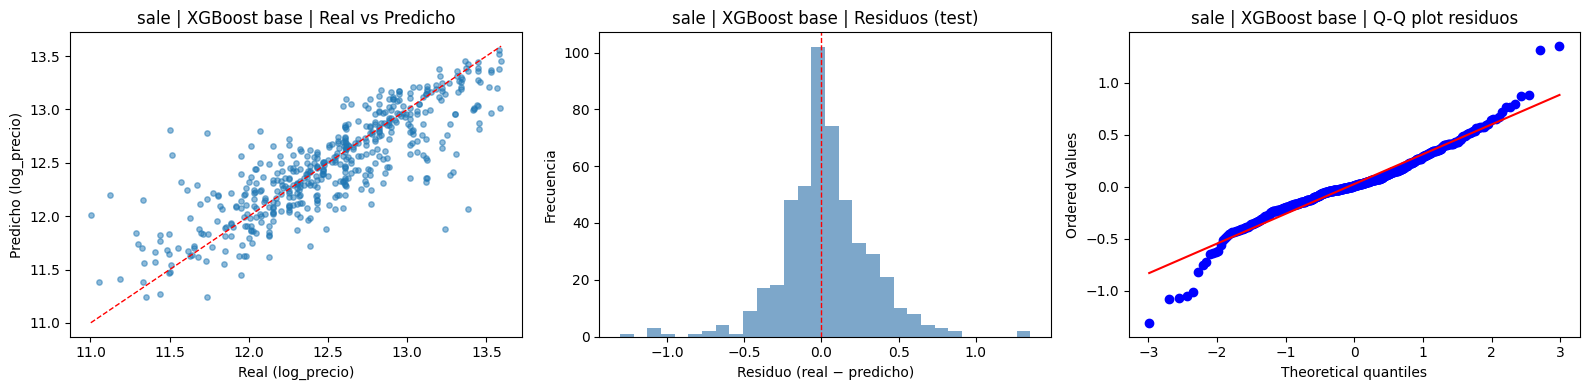

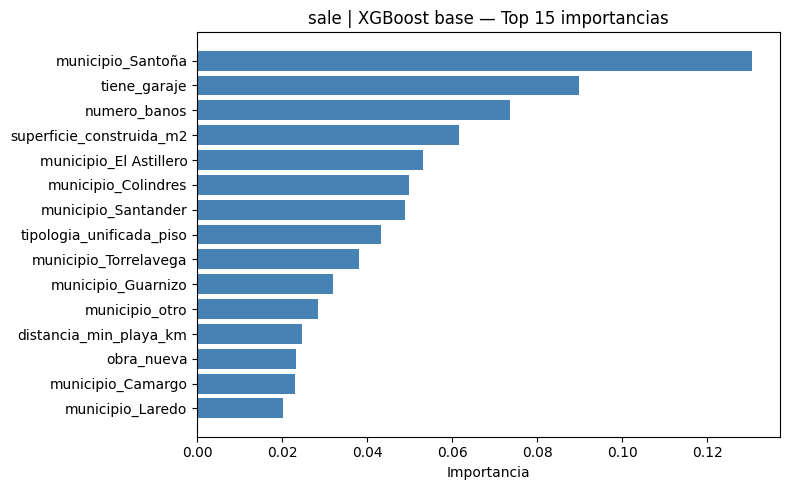


--- XGBoost | GridSearch (192 combinaciones, CV=5) ---
  Mejores params: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 400, 'reg_lambda': 5, 'subsample': 0.7}
  CV RMSE (mejor): 0.29339
split     MSE    RMSE     MAE      R2    MAPE
train 0.02889 0.16998 0.12305 0.90765 0.00995
   CV     NaN 0.29339     NaN     NaN     NaN
 test 0.08509 0.29170 0.20874 0.69745 0.01682
  Sobreajuste → ratio RMSE test/train: 1.7161 | delta R2: 0.2102


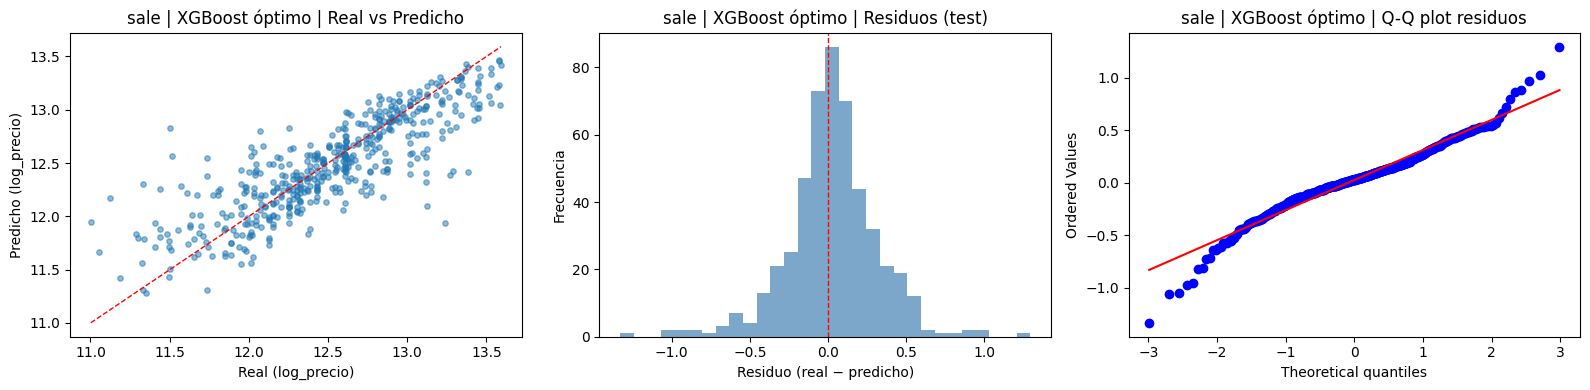

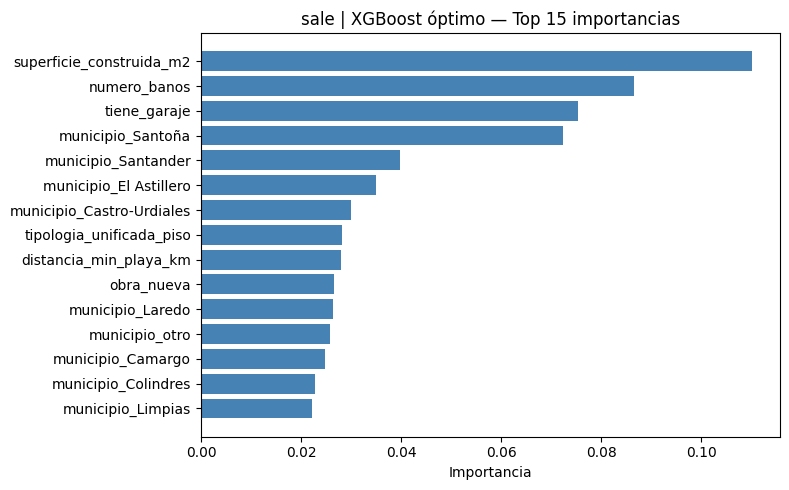


────────────────────────────────────────────────────────────
GRADIENT BOOSTING (sklearn)
────────────────────────────────────────────────────────────

--- GBR | Modelo base ---
split     MSE    RMSE     MAE      R2    MAPE
train 0.07528 0.27437 0.20682 0.75938 0.01673
 test 0.10310 0.32108 0.23782 0.63341 0.01918
  Sobreajuste → ratio RMSE test/train: 1.1702 | delta R2: 0.1260


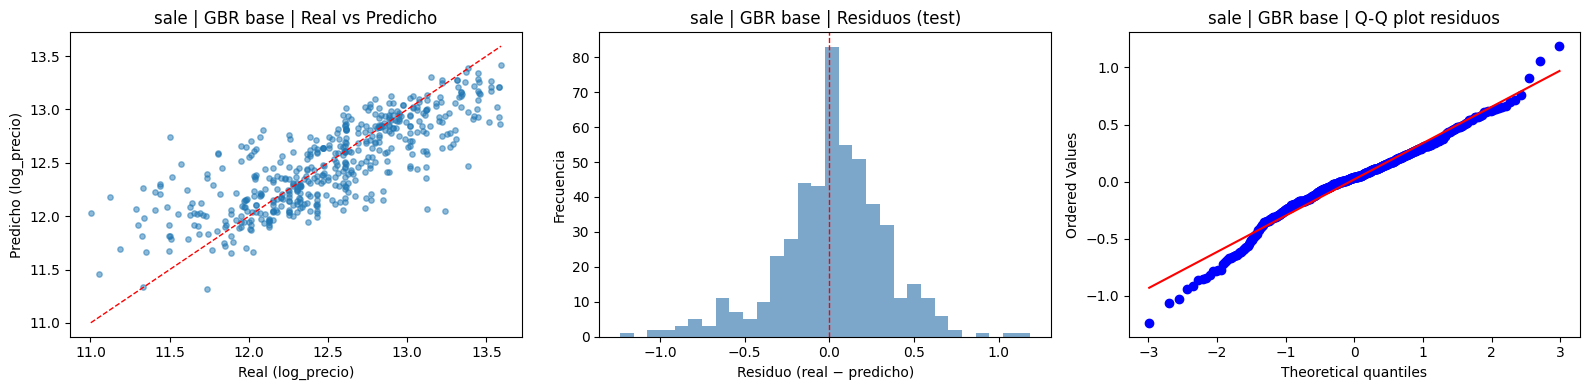

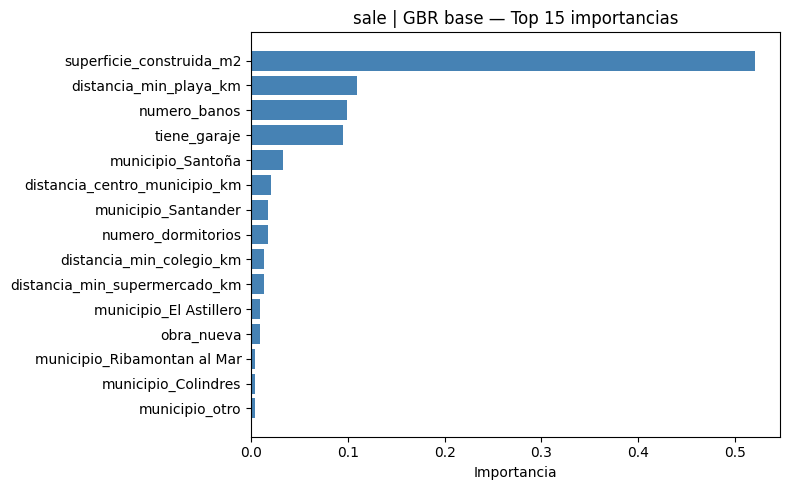


--- GBR | GridSearch (48 combinaciones, CV=5) ---
  Mejores params: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 400, 'subsample': 0.9}
  CV RMSE (mejor): 0.29472
split     MSE    RMSE     MAE      R2    MAPE
train 0.02430 0.15590 0.11220 0.92232 0.00907
   CV     NaN 0.29472     NaN     NaN     NaN
 test 0.08878 0.29797 0.21197 0.68430 0.01708
  Sobreajuste → ratio RMSE test/train: 1.9113 | delta R2: 0.2380


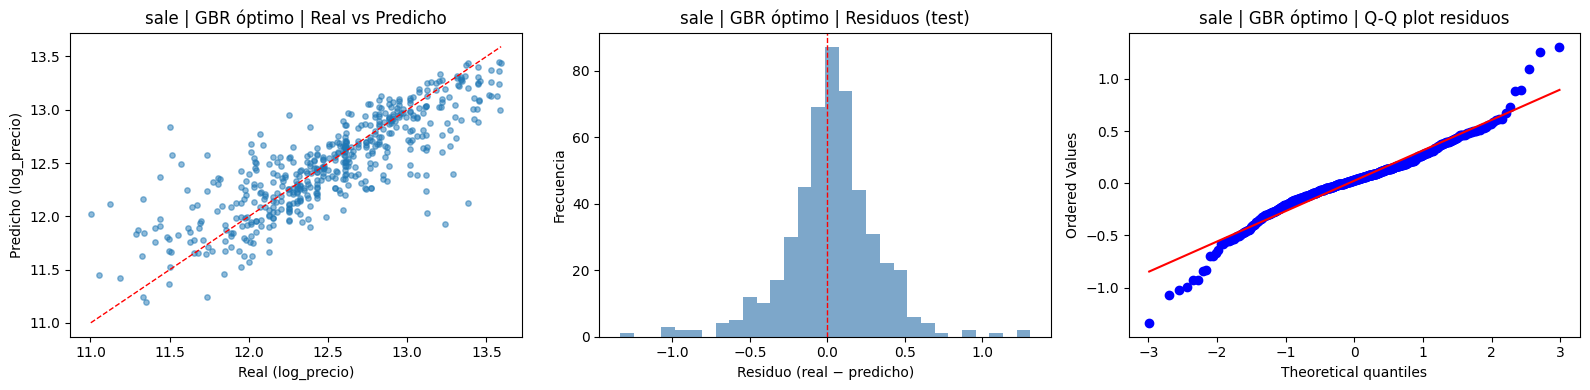

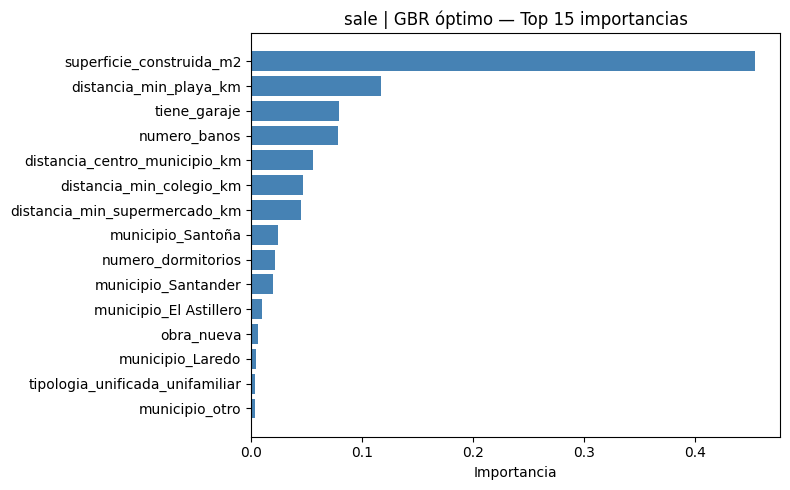


────────────────────────────────────────────────────────────
ADABOOST
────────────────────────────────────────────────────────────

--- AdaBoost | Modelo base ---
split     MSE    RMSE     MAE      R2    MAPE
train 0.13911 0.37297 0.30457 0.55537 0.02436
 test 0.14411 0.37961 0.30541 0.48759 0.02437
  Sobreajuste → ratio RMSE test/train: 1.0178 | delta R2: 0.0678


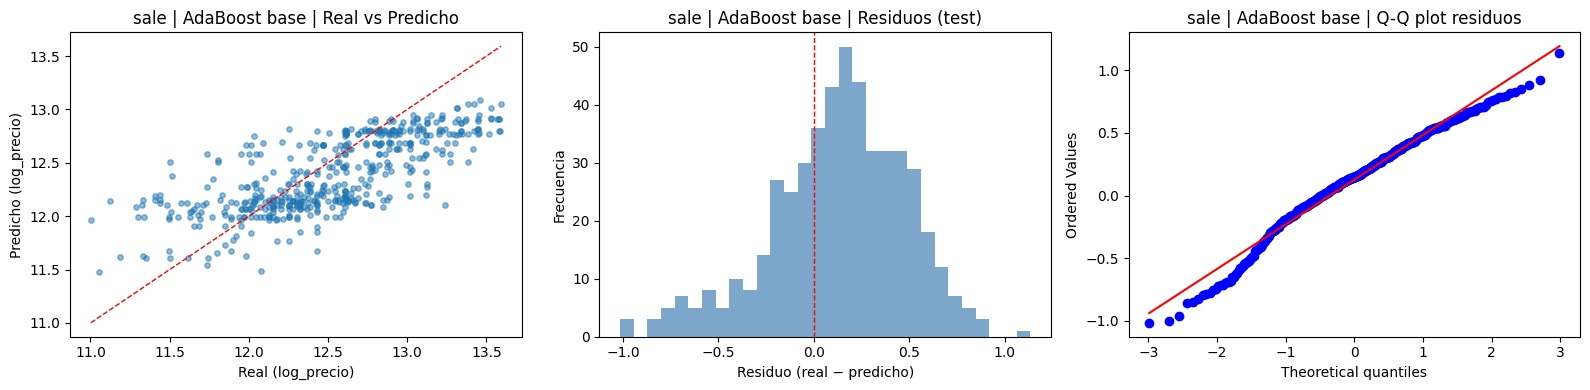

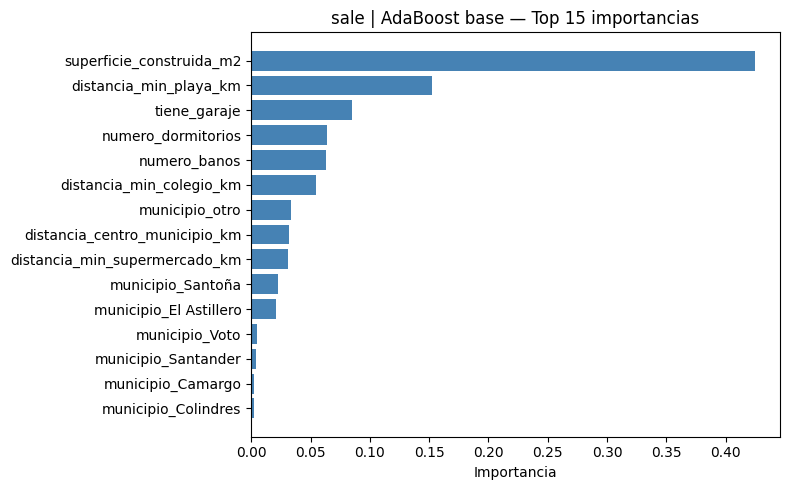


--- AdaBoost | GridSearch (27 combinaciones, CV=5) ---
  Mejores params: {'estimator__max_depth': 7, 'learning_rate': 1.0, 'n_estimators': 400}
  CV RMSE (mejor): 0.30999
split     MSE    RMSE     MAE      R2    MAPE
train 0.04098 0.20244 0.17274 0.86900 0.01384
   CV     NaN 0.30999     NaN     NaN     NaN
 test 0.09280 0.30463 0.23044 0.67001 0.01850
  Sobreajuste → ratio RMSE test/train: 1.5048 | delta R2: 0.1990


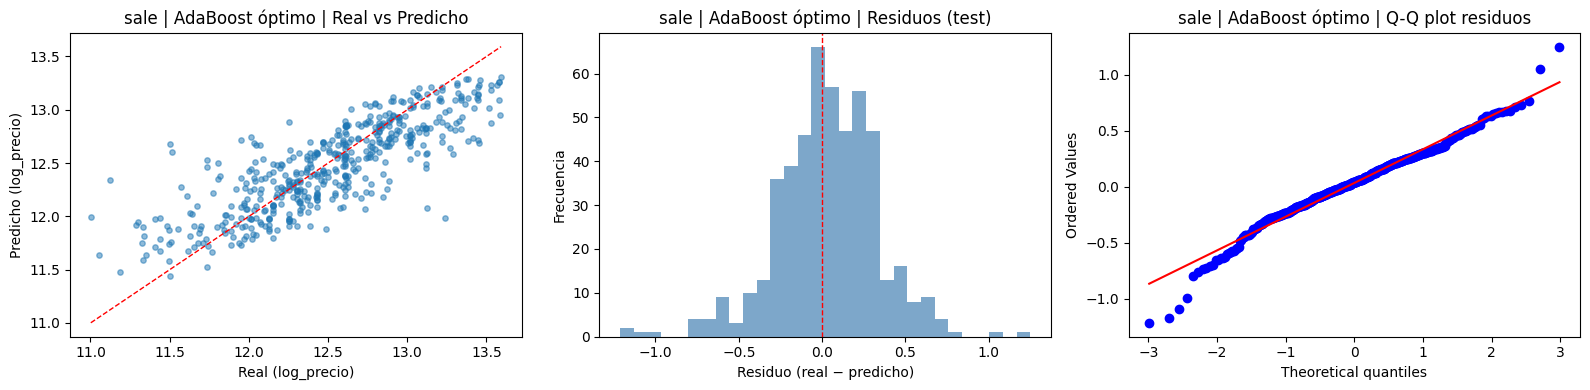

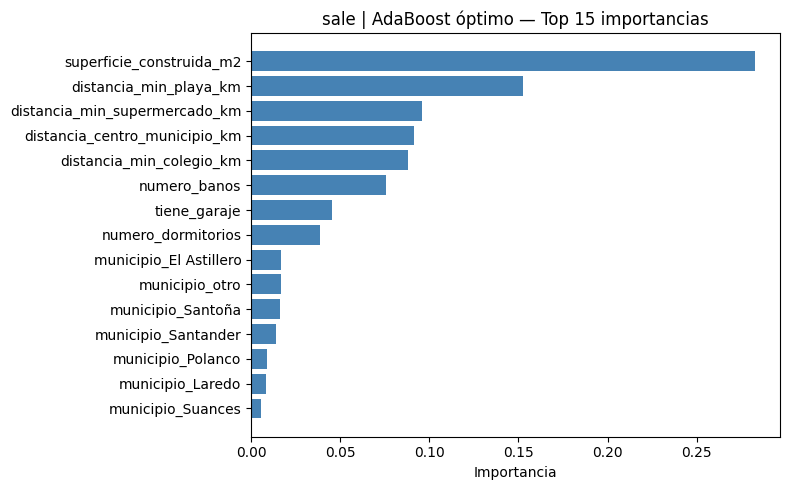


RESUMEN SALE — comparativa modelos
dataset   modelo   fase  train_RMSE  test_RMSE  train_R2  test_R2  cv_RMSE
   sale  XGBoost   base     0.07106    0.29369   0.98386  0.69330      NaN
   sale  XGBoost optimo     0.16998    0.29170   0.90765  0.69745  0.29339
   sale      GBR   base     0.27437    0.32108   0.75938  0.63341      NaN
   sale      GBR optimo     0.15590    0.29797   0.92232  0.68430  0.29472
   sale AdaBoost   base     0.37297    0.37961   0.55537  0.48759      NaN
   sale AdaBoost optimo     0.20244    0.30463   0.86900  0.67001  0.30999

DATASET: RENT
Filas cargadas: 702
Features finales: 20 | Filas: 702
Train: 561 | Test: 141

────────────────────────────────────────────────────────────
XGBOOST
────────────────────────────────────────────────────────────

--- XGBoost | Modelo base ---
split     MSE    RMSE     MAE      R2    MAPE
train 0.00002 0.00488 0.00335 0.99967 0.00049
 test 0.04192 0.20473 0.15127 0.37362 0.02203
  Sobreajuste → ratio RMSE test/train: 41.9529 

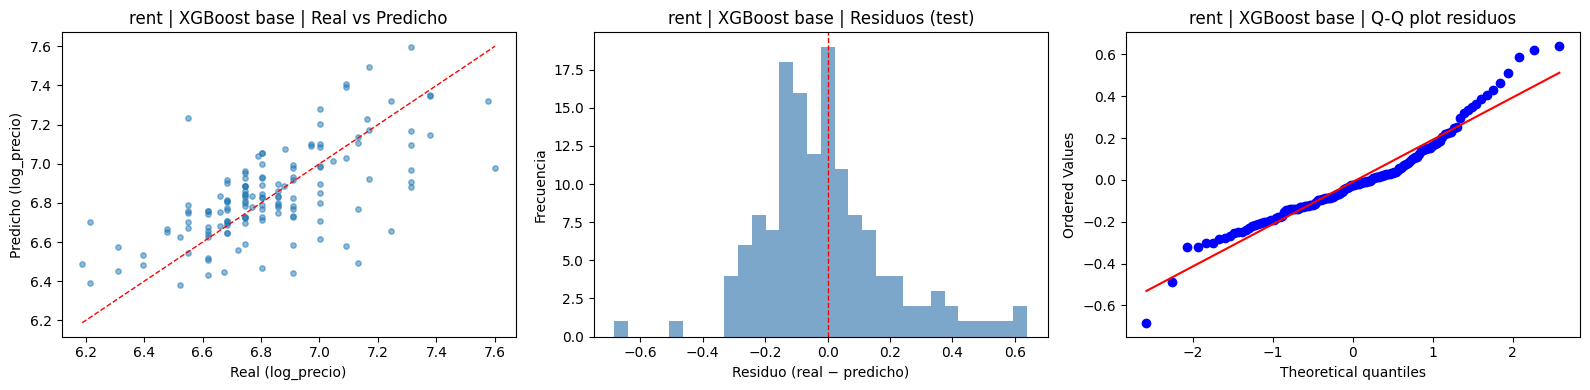

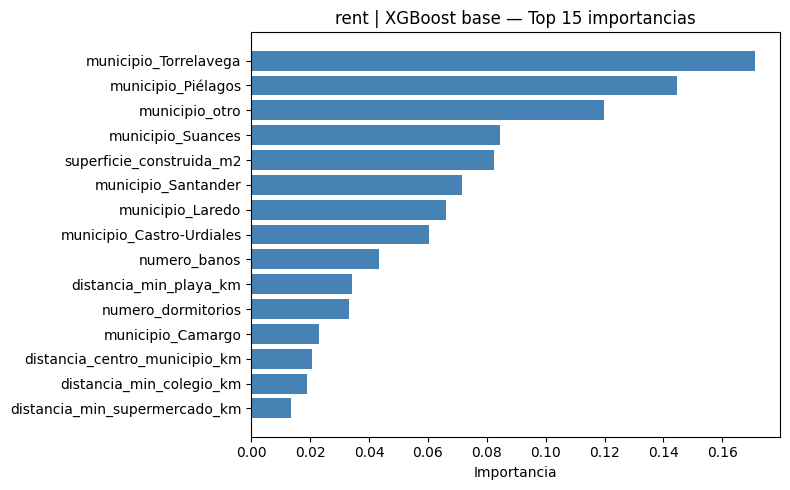


--- XGBoost | GridSearch (192 combinaciones, CV=5) ---
  Mejores params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 200, 'reg_lambda': 1, 'subsample': 0.7}
  CV RMSE (mejor): 0.18065
split     MSE    RMSE     MAE      R2    MAPE
train 0.01034 0.10169 0.07715 0.85656 0.01121
   CV     NaN 0.18065     NaN     NaN     NaN
 test 0.03933 0.19833 0.14547 0.41221 0.02125
  Sobreajuste → ratio RMSE test/train: 1.9503 | delta R2: 0.4443


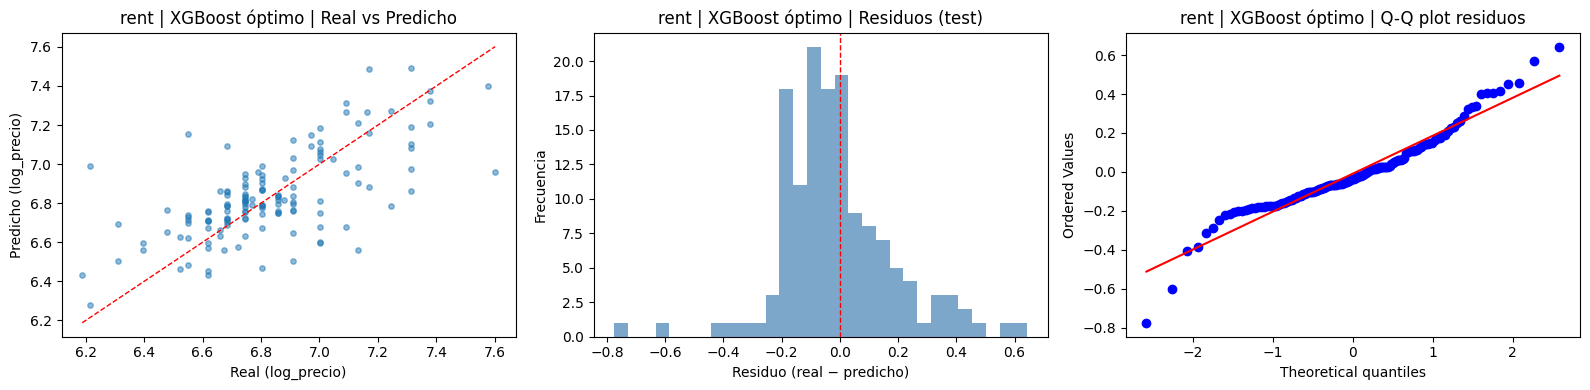

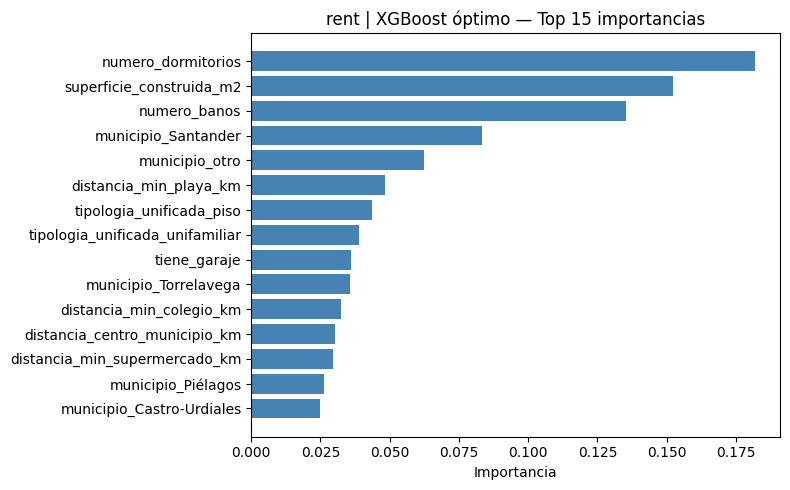


────────────────────────────────────────────────────────────
GRADIENT BOOSTING (sklearn)
────────────────────────────────────────────────────────────

--- GBR | Modelo base ---
split     MSE    RMSE     MAE      R2    MAPE
train 0.01355 0.11639 0.08759 0.81210 0.01273
 test 0.03674 0.19169 0.14165 0.45092 0.02071
  Sobreajuste → ratio RMSE test/train: 1.6470 | delta R2: 0.3612


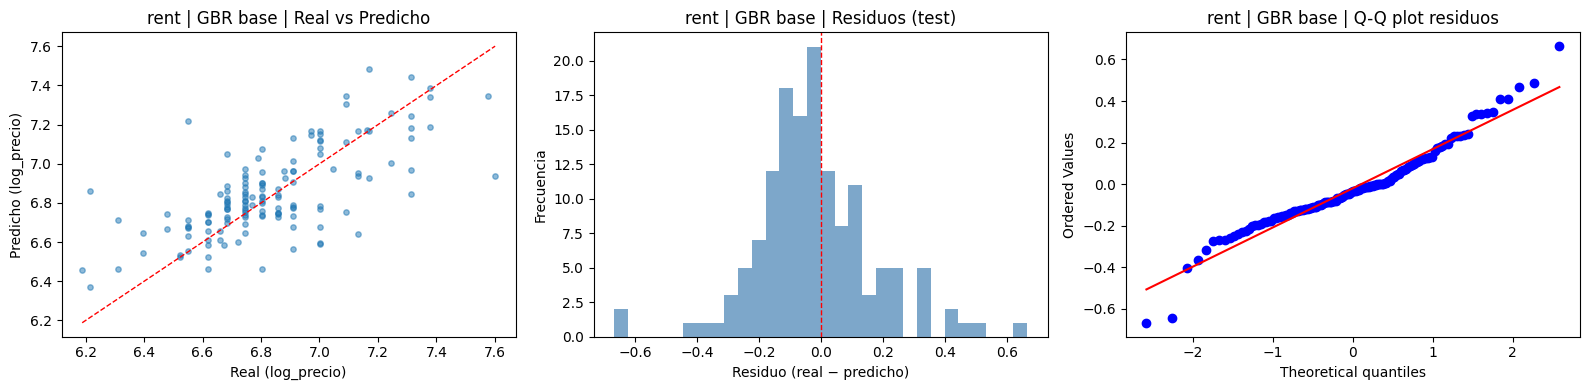

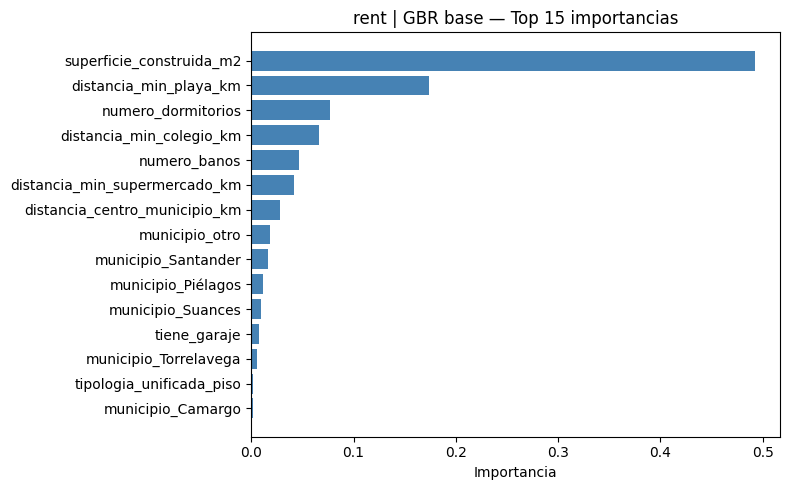


--- GBR | GridSearch (48 combinaciones, CV=5) ---
  Mejores params: {'learning_rate': 0.05, 'max_depth': 4, 'min_samples_leaf': 5, 'n_estimators': 200, 'subsample': 0.7}
  CV RMSE (mejor): 0.18315
split     MSE    RMSE     MAE      R2    MAPE
train 0.00930 0.09643 0.07286 0.87101 0.01058
   CV     NaN 0.18315     NaN     NaN     NaN
 test 0.04076 0.20188 0.14715 0.39097 0.02152
  Sobreajuste → ratio RMSE test/train: 2.0935 | delta R2: 0.4800


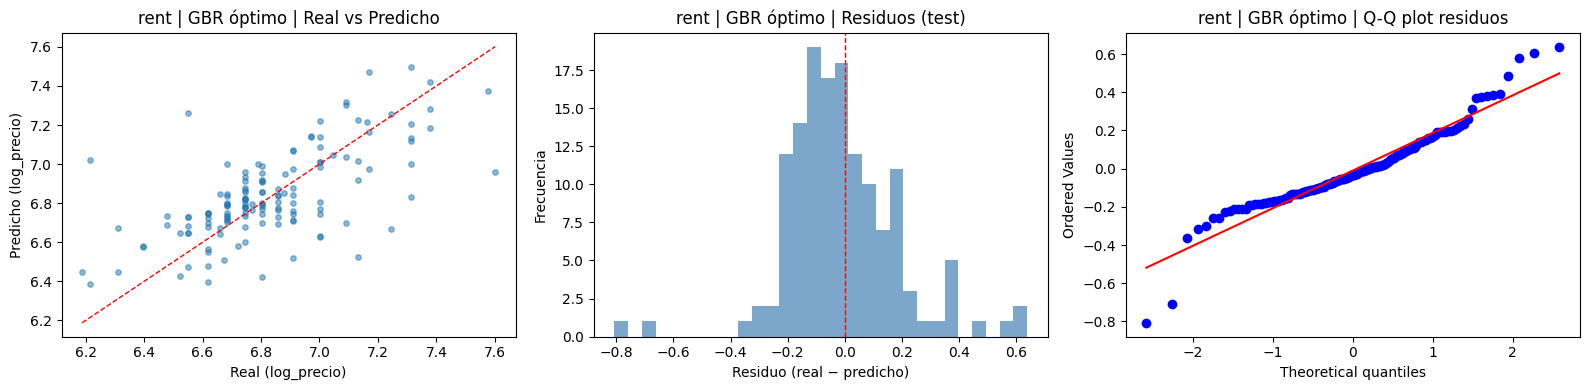

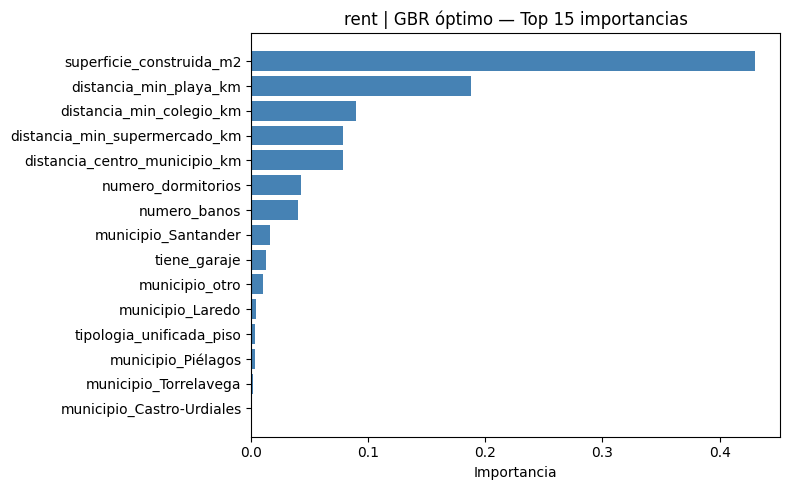


────────────────────────────────────────────────────────────
ADABOOST
────────────────────────────────────────────────────────────

--- AdaBoost | Modelo base ---
split     MSE    RMSE     MAE      R2    MAPE
train 0.02996 0.17308 0.14266 0.58446 0.02086
 test 0.04244 0.20601 0.15874 0.36582 0.02333
  Sobreajuste → ratio RMSE test/train: 1.1903 | delta R2: 0.2186


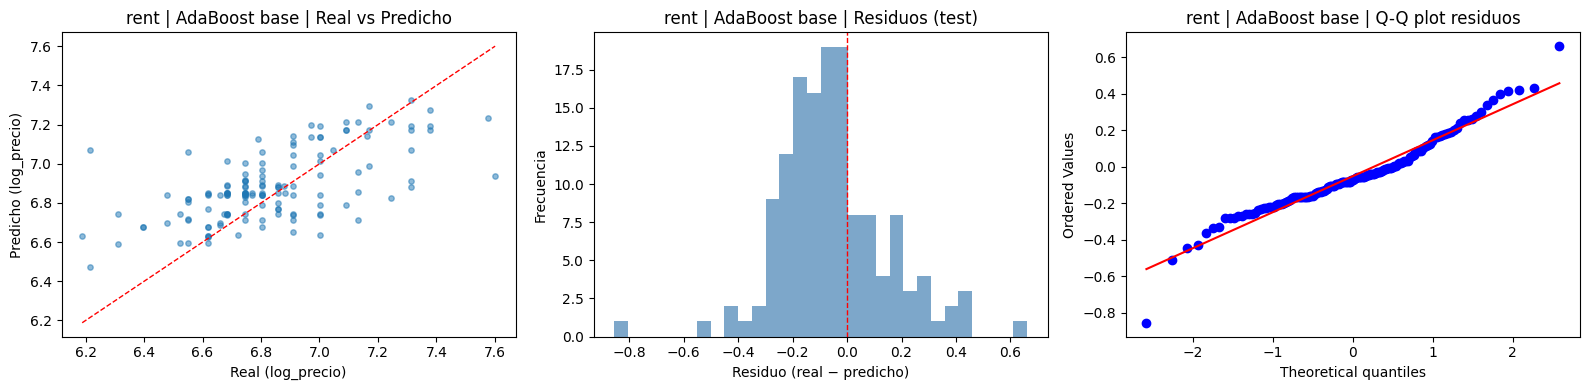

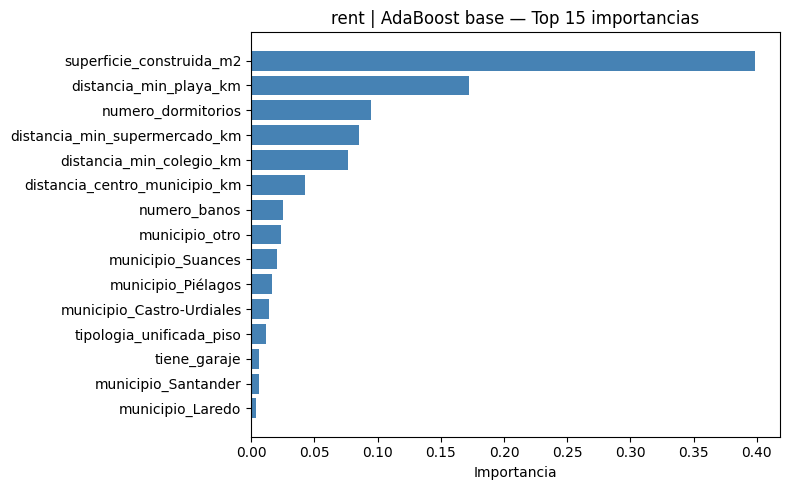


--- AdaBoost | GridSearch (27 combinaciones, CV=5) ---
  Mejores params: {'estimator__max_depth': 5, 'learning_rate': 1.5, 'n_estimators': 400}
  CV RMSE (mejor): 0.18423
split     MSE    RMSE     MAE      R2    MAPE
train 0.01408 0.11865 0.10258 0.80471 0.01498
   CV     NaN 0.18423     NaN     NaN     NaN
 test 0.03747 0.19356 0.14893 0.44012 0.02178
  Sobreajuste → ratio RMSE test/train: 1.6314 | delta R2: 0.3646


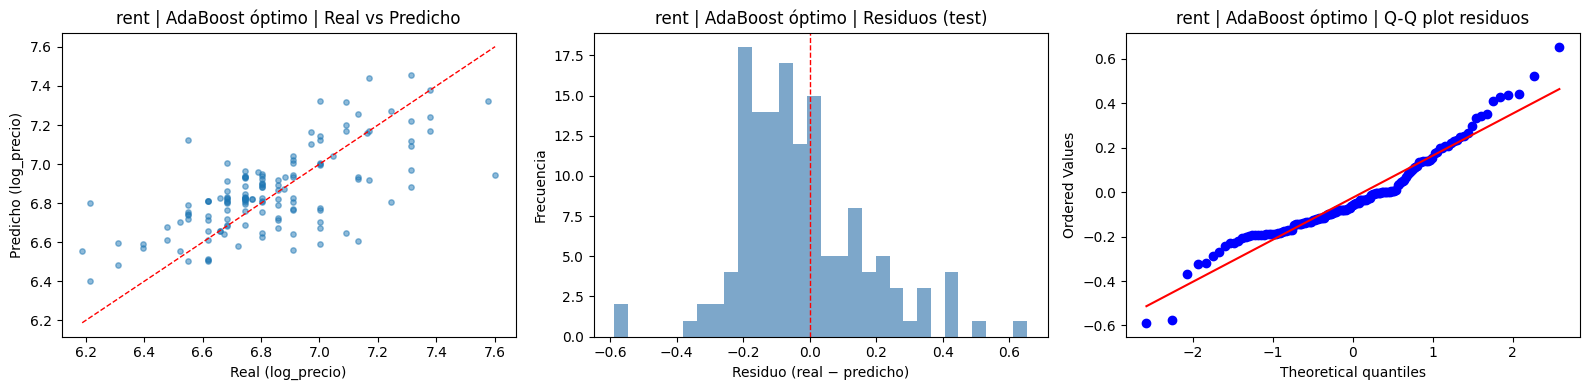

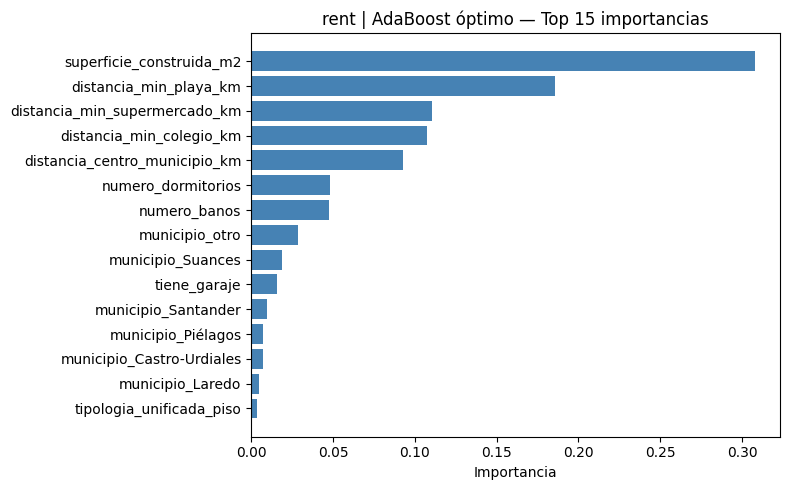


RESUMEN RENT — comparativa modelos
dataset   modelo   fase  train_RMSE  test_RMSE  train_R2  test_R2  cv_RMSE
   rent  XGBoost   base     0.00488    0.20473   0.99967  0.37362      NaN
   rent  XGBoost optimo     0.10169    0.19833   0.85656  0.41221  0.18065
   rent      GBR   base     0.11639    0.19169   0.81210  0.45092      NaN
   rent      GBR optimo     0.09643    0.20188   0.87101  0.39097  0.18315
   rent AdaBoost   base     0.17308    0.20601   0.58446  0.36582      NaN
   rent AdaBoost optimo     0.11865    0.19356   0.80471  0.44012  0.18423

RESUMEN GLOBAL
dataset   modelo   fase  train_RMSE  test_RMSE  train_R2  test_R2  cv_RMSE
   sale  XGBoost   base     0.07106    0.29369   0.98386  0.69330      NaN
   sale  XGBoost optimo     0.16998    0.29170   0.90765  0.69745  0.29339
   sale      GBR   base     0.27437    0.32108   0.75938  0.63341      NaN
   sale      GBR optimo     0.15590    0.29797   0.92232  0.68430  0.29472
   sale AdaBoost   base     0.37297    0.37961  

,dataset,modelo,fase,train_RMSE,test_RMSE,train_R2,test_R2,cv_RMSE
0,sale,XGBoost,base,0.07106,0.29369,0.98386,0.69330,NaN
1,sale,XGBoost,optimo,0.16998,0.29170,0.90765,0.69745,0.293388
2,sale,GBR,base,0.27437,0.32108,0.75938,0.63341,NaN
3,sale,GBR,optimo,0.15590,0.29797,0.92232,0.68430,0.294721
4,sale,AdaBoost,base,0.37297,0.37961,0.55537,0.48759,NaN
5,sale,AdaBoost,optimo,0.20244,0.30463,0.86900,0.67001,0.309989
6,rent,XGBoost,base,0.00488,0.20473,0.99967,0.37362,NaN
7,rent,XGBoost,optimo,0.10169,0.19833,0.85656,0.41221,0.180646
8,rent,GBR,base,0.11639,0.19169,0.81210,0.45092,NaN
9,rent,GBR,optimo,0.09643,0.20188,0.87101,0.39097,0.183151


In [4]:
# ── Bucle principal: un bloque por dataset ────────────────────────────────────

all_summary_rows = []

for dataset_name, dataset_path in DATASETS.items():
    print()
    print("=" * 100)
    print(f"DATASET: {dataset_name.upper()}")
    print("=" * 100)

    # ── Carga ─────────────────────────────────────────────────────────────────
    df = pd.read_csv(dataset_path)
    df = df[df[TARGET_COL].notna()].copy()
    print(f"Filas cargadas: {len(df)}")

    final_muni_cols = sorted([c for c in df.columns if c.startswith("municipio_")])

    # ── Preparar features ─────────────────────────────────────────────────────
    all_feature_cols = BASE_FEATURES + final_muni_cols
    X = prepare_X(df, all_feature_cols)
    y = df[TARGET_COL].reset_index(drop=True)

    # alinear índices tras reset del imputer
    y = df[TARGET_COL].values

    print(f"Features finales: {X.shape[1]} | Filas: {X.shape[0]}")

    # ── Split 80/20 ───────────────────────────────────────────────────────────
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    print(f"Train: {len(X_train)} | Test: {len(X_test)}")

    feature_names = X_train.columns.tolist()

    # ══════════════════════════════════════════════════════════════════════════
    # 1. XGBoost
    # ══════════════════════════════════════════════════════════════════════════
    print("\n" + "─" * 60)
    print("XGBOOST")
    print("─" * 60)

    # Base
    xgb_base = XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    xgb_base, xgb_base_train, xgb_base_test = run_base_model(
        xgb_base, X_train, X_test, y_train, y_test, "XGBoost", dataset_name
    )
    plot_diagnostics(y_test, xgb_base.predict(X_test), f"{dataset_name} | XGBoost base")
    fi_xgb_base = plot_feature_importance(
        xgb_base.feature_importances_, feature_names,
        f"{dataset_name} | XGBoost base — Top 15 importancias"
    )

    # Grid Search
    xgb_opt, xgb_gs, xgb_opt_train, xgb_opt_test, xgb_cv_rmse = run_grid_search(
        XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
        PARAM_GRID_XGB, X_train, X_test, y_train, y_test, "XGBoost", dataset_name
    )
    plot_diagnostics(y_test, xgb_opt.predict(X_test), f"{dataset_name} | XGBoost óptimo")
    fi_xgb_opt = plot_feature_importance(
        xgb_opt.feature_importances_, feature_names,
        f"{dataset_name} | XGBoost óptimo — Top 15 importancias"
    )

    # ══════════════════════════════════════════════════════════════════════════
    # 2. GradientBoosting
    # ══════════════════════════════════════════════════════════════════════════
    print("\n" + "─" * 60)
    print("GRADIENT BOOSTING (sklearn)")
    print("─" * 60)

    # Base
    gbr_base = GradientBoostingRegressor(random_state=RANDOM_STATE)
    gbr_base, gbr_base_train, gbr_base_test = run_base_model(
        gbr_base, X_train, X_test, y_train, y_test, "GBR", dataset_name
    )
    plot_diagnostics(y_test, gbr_base.predict(X_test), f"{dataset_name} | GBR base")
    fi_gbr_base = plot_feature_importance(
        gbr_base.feature_importances_, feature_names,
        f"{dataset_name} | GBR base — Top 15 importancias"
    )

    # Grid Search
    gbr_opt, gbr_gs, gbr_opt_train, gbr_opt_test, gbr_cv_rmse = run_grid_search(
        GradientBoostingRegressor(random_state=RANDOM_STATE),
        PARAM_GRID_GBR, X_train, X_test, y_train, y_test, "GBR", dataset_name
    )
    plot_diagnostics(y_test, gbr_opt.predict(X_test), f"{dataset_name} | GBR óptimo")
    fi_gbr_opt = plot_feature_importance(
        gbr_opt.feature_importances_, feature_names,
        f"{dataset_name} | GBR óptimo — Top 15 importancias"
    )

    # ══════════════════════════════════════════════════════════════════════════
    # 3. AdaBoost
    # ══════════════════════════════════════════════════════════════════════════
    print("\n" + "─" * 60)
    print("ADABOOST")
    print("─" * 60)

    # Base
    ada_base = AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=3),
        random_state=RANDOM_STATE,
    )
    ada_base, ada_base_train, ada_base_test = run_base_model(
        ada_base, X_train, X_test, y_train, y_test, "AdaBoost", dataset_name
    )
    plot_diagnostics(y_test, ada_base.predict(X_test), f"{dataset_name} | AdaBoost base")
    fi_ada_base = plot_feature_importance(
        ada_base.feature_importances_, feature_names,
        f"{dataset_name} | AdaBoost base — Top 15 importancias"
    )

    # Grid Search
    ada_opt, ada_gs, ada_opt_train, ada_opt_test, ada_cv_rmse = run_grid_search(
        AdaBoostRegressor(estimator=DecisionTreeRegressor(), random_state=RANDOM_STATE),
        PARAM_GRID_ADA, X_train, X_test, y_train, y_test, "AdaBoost", dataset_name
    )
    plot_diagnostics(y_test, ada_opt.predict(X_test), f"{dataset_name} | AdaBoost óptimo")
    fi_ada_opt = plot_feature_importance(
        ada_opt.feature_importances_, feature_names,
        f"{dataset_name} | AdaBoost óptimo — Top 15 importancias"
    )

    # ══════════════════════════════════════════════════════════════════════════
    # Resumen del dataset
    # ══════════════════════════════════════════════════════════════════════════
    print("\n" + "=" * 60)
    print(f"RESUMEN {dataset_name.upper()} — comparativa modelos")
    print("=" * 60)

    rows = [
        {"dataset": dataset_name, "modelo": "XGBoost",  "fase": "base",
         "train_RMSE": float(xgb_base_train["RMSE"].iloc[0]), "test_RMSE": float(xgb_base_test["RMSE"].iloc[0]),
         "train_R2":   float(xgb_base_train["R2"].iloc[0]),   "test_R2":   float(xgb_base_test["R2"].iloc[0]),   "cv_RMSE": None},
        {"dataset": dataset_name, "modelo": "XGBoost",  "fase": "optimo",
         "train_RMSE": float(xgb_opt_train["RMSE"].iloc[0]),  "test_RMSE": float(xgb_opt_test["RMSE"].iloc[0]),
         "train_R2":   float(xgb_opt_train["R2"].iloc[0]),    "test_R2":   float(xgb_opt_test["R2"].iloc[0]),    "cv_RMSE": xgb_cv_rmse},
        {"dataset": dataset_name, "modelo": "GBR",      "fase": "base",
         "train_RMSE": float(gbr_base_train["RMSE"].iloc[0]), "test_RMSE": float(gbr_base_test["RMSE"].iloc[0]),
         "train_R2":   float(gbr_base_train["R2"].iloc[0]),   "test_R2":   float(gbr_base_test["R2"].iloc[0]),   "cv_RMSE": None},
        {"dataset": dataset_name, "modelo": "GBR",      "fase": "optimo",
         "train_RMSE": float(gbr_opt_train["RMSE"].iloc[0]),  "test_RMSE": float(gbr_opt_test["RMSE"].iloc[0]),
         "train_R2":   float(gbr_opt_train["R2"].iloc[0]),    "test_R2":   float(gbr_opt_test["R2"].iloc[0]),    "cv_RMSE": gbr_cv_rmse},
        {"dataset": dataset_name, "modelo": "AdaBoost", "fase": "base",
         "train_RMSE": float(ada_base_train["RMSE"].iloc[0]), "test_RMSE": float(ada_base_test["RMSE"].iloc[0]),
         "train_R2":   float(ada_base_train["R2"].iloc[0]),   "test_R2":   float(ada_base_test["R2"].iloc[0]),   "cv_RMSE": None},
        {"dataset": dataset_name, "modelo": "AdaBoost", "fase": "optimo",
         "train_RMSE": float(ada_opt_train["RMSE"].iloc[0]),  "test_RMSE": float(ada_opt_test["RMSE"].iloc[0]),
         "train_R2":   float(ada_opt_train["R2"].iloc[0]),    "test_R2":   float(ada_opt_test["R2"].iloc[0]),    "cv_RMSE": ada_cv_rmse},
    ]
    all_summary_rows.extend(rows)

    ds_summary = pd.DataFrame(rows)
    print(ds_summary.round(5).to_string(index=False))

print()
print("=" * 100)
print("RESUMEN GLOBAL")
print("=" * 100)
global_summary = pd.DataFrame(all_summary_rows)
print(global_summary.round(5).to_string(index=False))
global_summary